# 02 · Missingness informativa: ¿la ausencia de un dato es una señal?

**Fase CRISP-DM: Comprensión de los datos (continuación) → puente a Preparación de los datos.**

En el notebook 01 ya mostramos, con evidencia, el tamaño del problema: el porcentaje de nulos
por variable (Sección 7), cuánto sabe realmente el dataset de cada paciente (misma sección),
una matriz de disponibilidad y el patrón hora a hora de un paciente concreto (Sección 8), y un
primer vistazo a las trayectorias de valores (Sección 9). También encontramos algo que
condiciona todo lo que sigue: **el registro de cada paciente se corta ~9 horas después del
inicio de sepsis**, casi sin excepción.

Este notebook no repite esos gráficos — parte de ellos. La pregunta que quedó abierta es más
fina: ¿por qué se agrupan los huecos como se agrupan, y **la decisión de pedir un examen
depende de si el paciente terminará séptico**? Si la respuesta es sí (y lo es, como vamos a
mostrar), la ausencia de un dato deja de ser un problema de calidad y pasa a ser una variable
predictiva por derecho propio — la base de las funciones `indicadores_medicion` y
`carga_de_monitoreo` que ya están escritas en `src/features.py`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path.cwd().parent / "src"))
import io_datos
import viz
import features
from config import cargar_config

cfg = cargar_config()
df = io_datos.leer_cohorte(cfg)
viz.aplicar_estilo()
pd.set_option("display.max_columns", 50)

## 1. ¿Los laboratorios se piden solos o en panel?

La matriz de disponibilidad del notebook 01 (Sección 8) mostraba bandas horizontales donde
varias columnas de labs se oscurecían **a la vez**. Lo confirmamos de forma cuantitativa
correlacionando los **indicadores de medición** (1 si esa hora tiene valor, 0 si no) entre
sí — no los valores clínicos, solo el hecho de haberse medido.

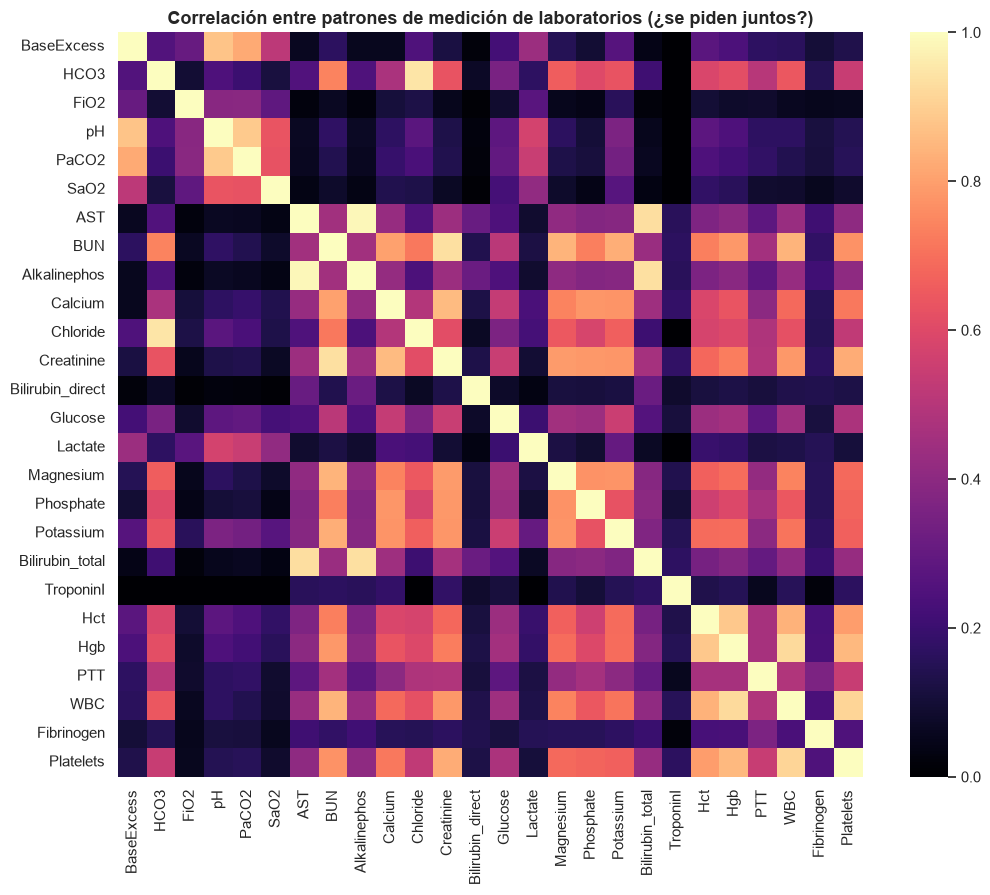

In [2]:
indicador = df[features.LABORATORIOS].notna().astype(int)
corr_indicador = indicador.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_indicador, cmap="magma", vmin=0, vmax=1, square=True, ax=ax)
ax.set_title("Correlación entre patrones de medición de laboratorios (¿se piden juntos?)")
plt.tight_layout()
plt.show()

In [3]:
pares = corr_indicador.where(np.triu(np.ones(corr_indicador.shape), k=1).astype(bool)).stack()
pares.sort_values(ascending=False).head(10).rename("correlación").to_frame()

,,correlación
AST,Alkalinephos,0.986791
HCO3,Chloride,0.948748
Alkalinephos,Bilirubin_total,0.936755
BUN,Creatinine,0.934360
AST,Bilirubin_total,0.931912
Hgb,WBC,0.922618
WBC,Platelets,0.912851
pH,PaCO2,0.887858
Hct,Hgb,0.886717
BaseExcess,pH,0.877231


Los diez pares con más correlación no son ruido, son **paneles clínicos reales**: `AST`–
`Alkalinephos` (0,99) y `Alkalinephos`–`Bilirubin_total` (0,94) son el panel hepático;
`HCO3`–`Chloride` (0,95) y `pH`–`PaCO2`/`BaseExcess` (0,89/0,88) son la gasometría;
`BUN`–`Creatinine` (0,93) es función renal; `Hgb`–`WBC`–`Platelets`–`Hct` (0,89–0,92) es el
hemograma. **La ausencia de datos sigue la lógica de qué panel se ordenó**, no el azar — el
patrón de disponibilidad codifica el protocolo médico real que hay detrás del dataset.

## 2. ¿Se monitorea igual a alguien que lleva 3 horas que a alguien que lleva 5 días?

Agrupamos las horas en bloques según cuánto tiempo lleva el paciente en la UCI y calculamos,
para cada variable, el porcentaje de mediciones no nulas dentro de cada bloque. La pregunta es
si la intensidad de vigilancia es constante o cambia con la duración de la estancia.

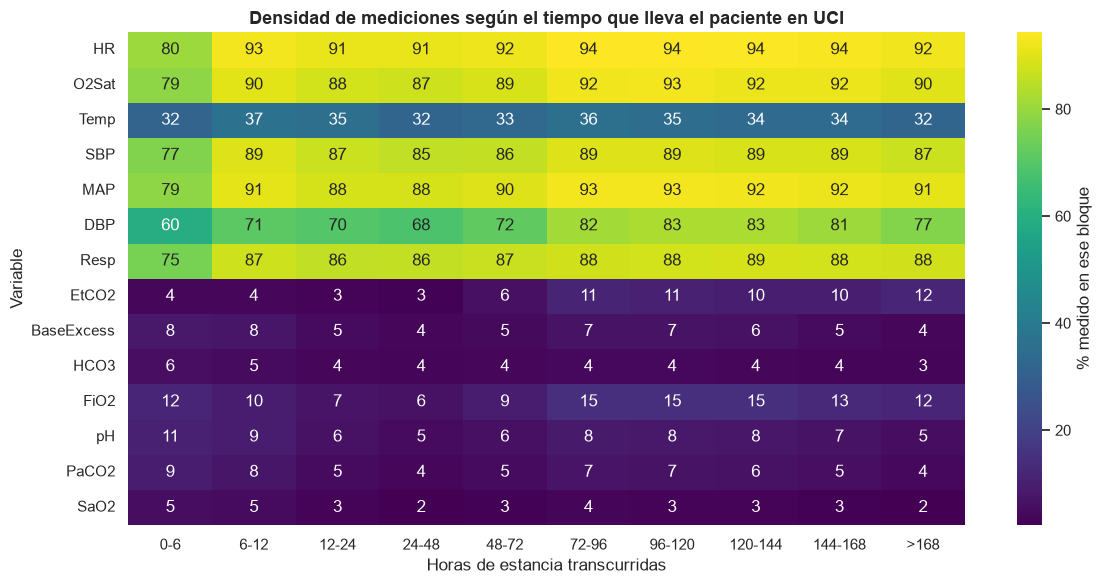

Horas de registro por bloque (tamaño de cada columna del heatmap):
bloque_estancia
0-6        222667
6-12       238840
12-24      430462
24-48      520913
48-72       72254
72-96       20776
96-120      14250
120-144      9973
144-168      7083
>168        14992


In [4]:
bins = [0, 6, 12, 24, 48, 72, 96, 120, 144, 168, np.inf]
etiquetas = ["0-6", "6-12", "12-24", "24-48", "48-72", "72-96", "96-120", "120-144", "144-168", ">168"]
df["bloque_estancia"] = pd.cut(df["ICULOS"], bins=bins, labels=etiquetas, right=True)

gases = ["EtCO2", "BaseExcess", "HCO3", "FiO2", "pH", "PaCO2", "SaO2"]
variables_densidad = features.VITALES[:7] + gases
densidad = df.groupby("bloque_estancia", observed=True)[variables_densidad].apply(lambda g: g.notna().mean() * 100)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(densidad.T, cmap="viridis", annot=True, fmt=".0f",
            cbar_kws={"label": "% medido en ese bloque"}, ax=ax)
ax.set_xlabel("Horas de estancia transcurridas")
ax.set_ylabel("Variable")
ax.set_title("Densidad de mediciones según el tiempo que lleva el paciente en UCI")
plt.tight_layout()
plt.show()

print("Horas de registro por bloque (tamaño de cada columna del heatmap):")
print(df["bloque_estancia"].value_counts().sort_index().to_string())

Los signos vitales son casi planos en toda la fila (75–94% siempre) — su monitoreo no depende
de cuánto lleve el paciente. Los **gases arteriales cuentan otra historia**: `EtCO2` pasa de
3,8% en las primeras 6 horas a 11,6% después de 168 horas, y `pH`/`PaCO2` se **duplican**
entre el primer bloque y el rango 96–120h. La lectura clínica es directa: estos exámenes se
piden con esa frecuencia en pacientes con **soporte ventilatorio o línea arterial**, algo que
se instala después del manejo inicial, no al ingreso. Que la densidad de gases suba con la
duración de la estancia es, indirectamente, una medida de qué tan complicado se ha vuelto el
caso. Ojo con la lectura de esta tabla, eso sí: los bloques más allá de 72h tienen muy pocas
horas detrás (ver conteo impreso arriba — de 520.913 horas en el bloque 24-48h a solo 14.992
en `>168h`), así que sus porcentajes son más ruidosos.

## 3. La pregunta central: ¿pedir un laboratorio depende de si el paciente es séptico?

Esta es la hipótesis que sostiene buena parte del feature engineering del notebook 05. Si el
personal clínico sospecha sepsis, es de esperar que pida ciertos exámenes —sobre todo
lactato— con más frecuencia que a un paciente sin esa sospecha. Lo contrastamos comparando,
para cada paciente, si alguna vez desarrolla sepsis, contra la probabilidad de que un lab se
mida en una hora cualquiera de su estancia.

In [5]:
df["_septico_paciente"] = df.groupby("pid", observed=True)["SepsisLabel"].transform("max")

labs_clave = ["Lactate", "FiO2", "pH", "BUN", "WBC", "Creatinine", "Platelets", "Glucose"]
tabla_informativa = pd.DataFrame({
    "medido_si_septico_%": [round(df.loc[df._septico_paciente == 1, c].notna().mean() * 100, 2) for c in labs_clave],
    "medido_si_control_%": [round(df.loc[df._septico_paciente == 0, c].notna().mean() * 100, 2) for c in labs_clave],
}, index=labs_clave)
tabla_informativa["razon"] = (tabla_informativa.iloc[:, 0] / tabla_informativa.iloc[:, 1]).round(2)
tabla_informativa.sort_values("razon", ascending=False)

,medido_si_septico_%,medido_si_control_%,razon
Lactate,5.38,2.33,2.31
FiO2,16.74,7.28,2.30
pH,11.14,6.40,1.74
BUN,8.12,6.71,1.21
WBC,7.38,6.29,1.17
Creatinine,6.84,6.00,1.14
Platelets,6.55,5.86,1.12
Glucose,17.89,17.01,1.05


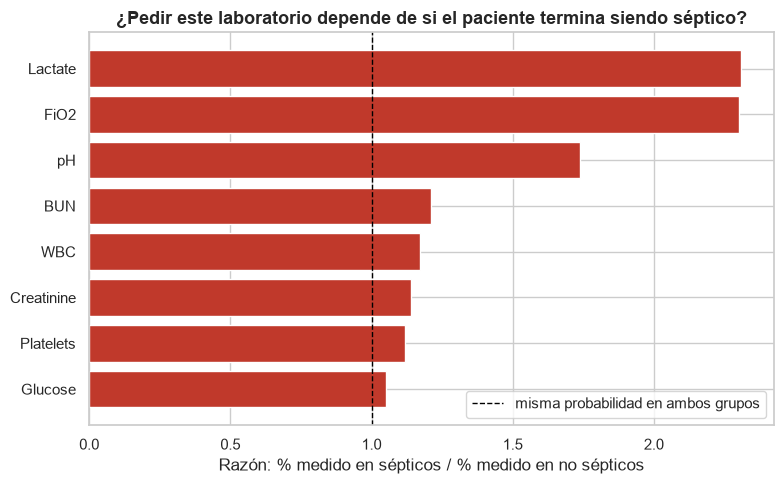

In [6]:
t = tabla_informativa.sort_values("razon")
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(t.index, t["razon"], color=[viz.COLOR_SEPSIS if v > 1 else viz.COLOR_CONTROL for v in t["razon"]])
ax.axvline(1, color="black", ls="--", lw=1, label="misma probabilidad en ambos grupos")
ax.set_xlabel("Razón: % medido en sépticos / % medido en no sépticos")
ax.set_title("¿Pedir este laboratorio depende de si el paciente termina siendo séptico?")
ax.legend()
plt.tight_layout()
plt.show()

Confirmado, y con un patrón clínicamente coherente: **Lactato se mide 2,31 veces más** en
horas de pacientes que terminan siendo sépticos (5,38% vs 2,33% de las horas), y **FiO2 2,30
veces más** (16,74% vs 7,28%) — ambos son exactamente los marcadores que un clínico pediría
ante la sospecha de shock séptico (lactato, hipoperfusión) o de necesidad de soporte
respiratorio (FiO2). `pH` también destaca (1,74x). En el otro extremo, `Glucose` tiene razón
1,05 — prácticamente igual en ambos grupos, porque se pide de rutina a casi todo el mundo,
séptico o no, y por eso no distingue.


## 4. ¿La intensidad de monitoreo cambia *cerca* del momento del evento?

Falta cerrar el círculo temporal: ¿la carga de laboratorios sube justo antes o después de que
se declare la sepsis, o el efecto de la Sección 3 es solo un promedio de toda la estancia?
Alineamos a cada paciente séptico respecto a su propia hora de inicio (hora 0 = onset), con la
misma ventana `(-24, +9)` que fijamos en el notebook 01 por el corte de datos.

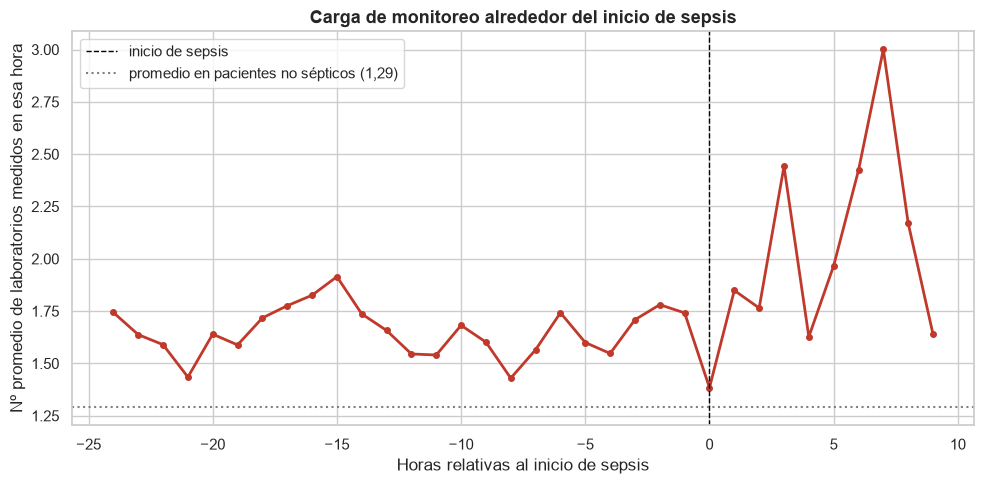

In [7]:
onset = df.loc[df.SepsisLabel == 1].groupby("pid", observed=True)["ICULOS"].min()
df["horas_hasta_sepsis"] = df["ICULOS"] - df["pid"].map(onset.reindex(df["pid"].cat.categories))

ventana = df[df["pid"].isin(onset.index) & df["horas_hasta_sepsis"].between(-24, 9)]
carga = ventana.groupby("horas_hasta_sepsis")[features.LABORATORIOS].apply(lambda g: g.notna().sum(axis=1).mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(carga.index, carga.values, color=viz.COLOR_SEPSIS, lw=2, marker="o", ms=4)
ax.axvline(0, color="black", ls="--", lw=1, label="inicio de sepsis")
ax.axhline(1.29, color="grey", ls=":", lw=1.5, label="promedio en pacientes no sépticos (1,29)")
ax.set_xlabel("Horas relativas al inicio de sepsis")
ax.set_ylabel("Nº promedio de laboratorios medidos en esa hora")
ax.set_title("Carga de monitoreo alrededor del inicio de sepsis")
ax.legend()
plt.tight_layout()
plt.show()

La carga **ya está por encima del baseline de los no sépticos (1,29) desde la hora −24** —
coherente con la Sección 3: a estos pacientes ya se les vigila más de cerca, incluso mucho
antes del evento. Pero dentro de esa ventana previa **no hay una tendencia clara de subida**:
oscila entre 1,4 y 1,9 sin patrón, y **da un salto marcado a partir de la hora +3** (llega a
3,00 en la hora +7). La lectura honesta es específica: la missingness informativa funciona
como una señal **sostenida durante toda la estancia** (Sección 3), no como una **alarma de
última hora** que se dispare justo antes del evento — es la respuesta clínica al diagnóstico
ya confirmado la que dispara el salto, no una anticipación fina hora a hora.

## 5. Qué sabemos al cerrar este notebook

- **La ausencia de datos sigue el protocolo médico, no el azar**: los labs se piden en
  paneles (hepático, renal, gasometría, hemograma) — confirmado con evidencia cuantitativa,
  no solo con la inspección visual del notebook 01.
- **La intensidad de monitoreo depende de cuánto lleva el paciente en UCI**: los gases
  arteriales se piden hasta el doble de frecuente en estancias largas, reflejo indirecto de
  soporte ventilatorio o líneas invasivas instaladas con el tiempo.
- **Missingness informativa confirmada, con número exacto**: lactato y FiO2 se piden ~2,3
  veces más en pacientes que terminan siendo sépticos. Justifica directamente las features de
  `indicadores_medicion` y `carga_de_monitoreo` ya construidas en `src/features.py`.
- **La señal es de vigilancia sostenida, no de alarma repentina**: la carga de labs ya está
  elevada 24h antes del evento respecto al baseline, pero solo salta con fuerza después —
  matiza cuánta "anticipación" real puede extraer el modelo de esta sola señal.

